# BÀI TẬP: EDA HOÀN CHỈNH — TITANIC
## Data Profiling → Descriptive Statistics → Define the Question
**Nguồn:** kaggle.com/c/titanic (891 dòng)

```
PHẦN A — DATA PROFILING       : dữ liệu sạch chưa, có gì
PHẦN B — DESCRIPTIVE STATS    : từng biến trông như thế nào
PHẦN C — DEFINE THE QUESTION  : đặt câu hỏi kinh doanh, trả lời bằng code, rút insight
```

## Setup

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [4]:
# TODO
print(df.shape)
df.info()

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


## A.2. Missing values & Duplicate data

In [10]:
# TODO
missing = df.isnull().sum()
print("Số dữ liệu bị mất: ")
print(missing[missing>0] if missing.sum()>0 else "Không có dữ liệu bị mất")
dulicate = df.duplicated().sum()
print("Số dữ liệu trùng: ", df.duplicated().sum())


Số dữ liệu bị mất: 
age            177
embarked         2
deck           688
embark_town      2
dtype: int64
Số dữ liệu trùng:  107


## A.3. Invalid values

In [ ]:
# TODO
print("Survied ngoài [0,1]: ", ((df['survived']) < 0 | (df['survived']>1)).sum())
print("Pclass ngoài [1,3]: ", ((df['pclass']<1) | (df['pclass']>3)).sum())
print("Age<=0: ", (df['age']<=0).sum())
print("Fare<=0: ", (df['fare']<0).sum())
print("Nhìn chung dữ liệu không sạch nhiều dữ liệu bị mất, trùng lập")

Survied ngoài [0,1]:  0
Pclass ngoài [1,3]:  0
Age<=0:  0
Fare<=0:  0
Nhìn chung dữ liệu không sạch nhiều dữ liệu bị mất, trung lập


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [28]:
# TODO
df['family_size'] = df['sibsp']+df['parch']+1
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [8]:
# TODO
for col in ['age', 'fare']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_: .2f}, Median={median_: .2f}, Mode={mode_: .2f}")

age: Mean= 29.70, Median= 28.00, Mode= 24.00
fare: Mean= 32.20, Median= 14.45, Mode= 8.05


## Group 2 — Dispersion

In [7]:
# TODO
for col in ['age', 'fare']:
    s = df[col]
    range_ = s.max() - s.min()
    var_ = s.var()
    std_ = s.std()
    q1,q3 = s.quantile([0.25, 0.75]); iqr = q3 - q1
    cv = std_/s.mean()
    print(f"---- {col} ----")
    print(f"Range={range_: .2f}, Var={var_: .2f}, STD={std_: .2f}, IQR={iqr: .2f}, CV={cv: .2f}")

---- age ----
Range= 79.58, Var= 211.02, STD= 14.53, IQR= 17.88, CV= 0.49
---- fare ----
Range= 512.33, Var= 2469.44, STD= 49.69, IQR= 23.09, CV= 1.54


## Group 3 — Location and Shape

---- age ----
PS25= 20.12, PS50= 28.00, PS75= 38.00
Skewness= 0.39, Kurtosis= 0.17


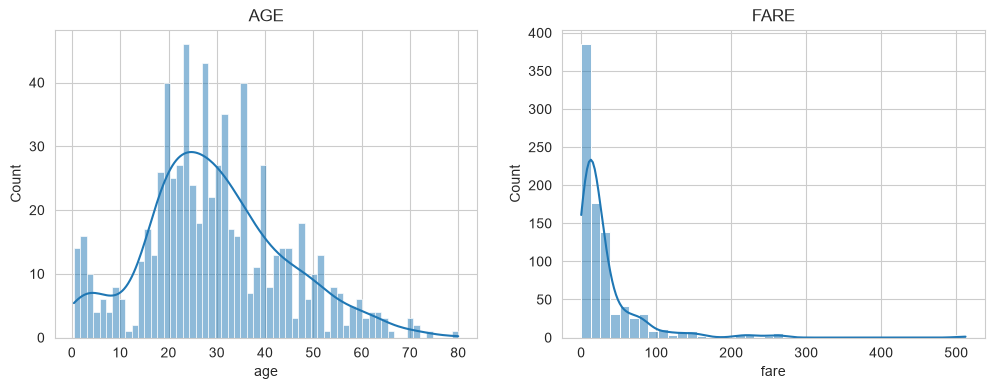

Nhận xét: Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuaạn cực đoan hơn
---- fare ----
PS25= 7.91, PS50= 14.45, PS75= 31.00
Skewness= 4.78, Kurtosis= 33.20


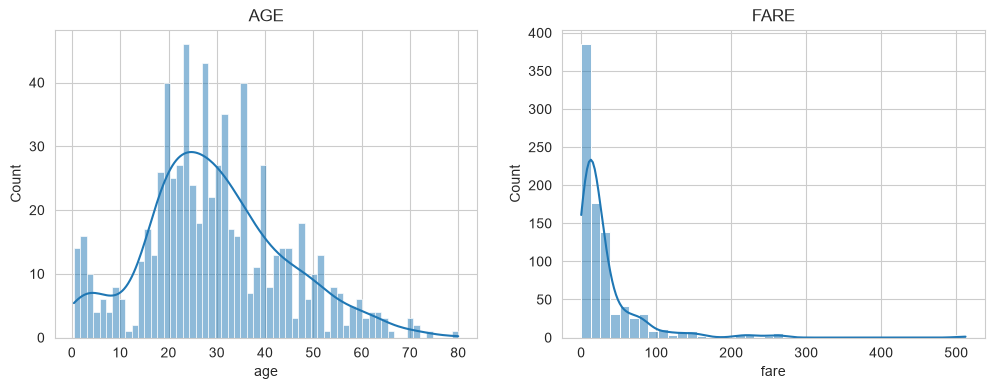

Nhận xét: Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuaạn cực đoan hơn


In [ ]:
# TODO
for col in ['age', 'fare']:
    s = df[col].dropna()
    skew_,kurt_ = stats.skew(s) , stats.kurtosis(s)
    print(f"---- {col} ----")
    print(f"PS25={s.quantile(0.25): .2f}, PS50={s.quantile(0.5): .2f}, PS75={s.quantile(0.75): .2f}")
    print(f"Skewness={skew_: .2f}, Kurtosis={kurt_: .2f}");

    fig,axes = plt.subplots(1,2,figsize=(12,4))
    sns.histplot(df['age'], bins=60, kde=True,ax=axes[0]); axes[0].set_title('AGE')
    sns.histplot(df['fare'], bins=40, kde=True, ax=axes[1]); axes[1].set_title('FARE')
    plt.tight_layout; plt.show()


    print("Nhận xét: Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuận cực đoan hơn")

---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

In [8]:
hang_ve = df.groupby('pclass').agg(
    song_sot=('survived', 'sum'),
    tong_so=('survived', 'count')
).reset_index()

hang_ve['tyle_song_sot'] = hang_ve['song_sot'] / hang_ve['tong_so'] * 100

hang_ve = hang_ve.sort_values('tyle_song_sot', ascending=False)
do_chenh_lech = hang_ve['tyle_song_sot'].max() - hang_ve['tyle_song_sot'].min()

print(hang_ve)
print("Sự chênh lệch giữa hạng cao nhất và hạng thấp nhất là:", do_chenh_lech,"%")

   pclass  song_sot  tong_so  tyle_song_sot
0       1       136      216      62.962963
1       2        87      184      47.282609
2       3       119      491      24.236253
Sự chênh lệch giữa hạng cao nhất và hạng thấp nhất là: 38.726710417138115 %


## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [12]:
# TODO
gioi_tinh = df.groupby('sex').agg(
    song_sot = ('survived', 'sum'),
    tongso_song_sot = ('survived', 'count')
)

gioi_tinh['tyle_song_sot'] = (gioi_tinh['song_sot'] / gioi_tinh['tongso_song_sot']) *100

hang_ve = df.groupby('pclass').agg(
    song_sot=('survived', 'sum'),
    tong_so_song_sot=('survived', 'count')
)

hang_ve['tyle_song_sot'] = hang_ve['song_sot'] / hang_ve['tong_so_song_sot'] * 100
print(gioi_tinh)
print()
print(hang_ve)
do_chenh_lech_GT  = gioi_tinh['tyle_song_sot'].max() - gioi_tinh['tyle_song_sot'].min()
do_chenh_lech_HV = hang_ve['tyle_song_sot'].max() - hang_ve['tyle_song_sot'].min()
print("Độ chênh lệch tỷ lệ sống của giới tính là", do_chenh_lech_GT,"%")
print("Độ chênh lệch tỷ lệ sống của hạng vé là", do_chenh_lech_HV,"%")
print("Do độ chênh lệch tỷ lệ sống của giới tính lớn hơn của hạng vé")
print("-> giới tính ảnh hưởng đến độ sống sot mạnh hơn")

        song_sot  tongso_song_sot  tyle_song_sot
sex                                             
female       233              314      74.203822
male         109              577      18.890815

        song_sot  tong_so_song_sot  tyle_song_sot
pclass                                           
1            136               216      62.962963
2             87               184      47.282609
3            119               491      24.236253
Độ chênh lệch tỷ lệ sống của giới tính là 55.31300709799203 %
Độ chênh lệch tỷ lệ sống của hạng vé là 38.726710417138115 %
Do độ chênh lệch tỷ lệ sống của giới tính lớn hơn của hạng vé
-> giới tính ảnh hưởng đến độ sống sot mạnh hơn


## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

In [25]:
fare_survived = df.groupby('survived').agg(
    fare_mean = ('fare', 'mean'),
    fare_median = ('fare', 'median'),
    so_luong = ('fare', 'count')
    
).reset_index()
print(fare_survived)
print()
print("Theo số liệu ta thấy nhóm sống sót co giá vé trung bình là 48.395408 lớn hơn nhóm không sống sót là 22.117887")
print()
print("-> Giá vé mắc hơn thì khả năng sống sót cao hơn")


   survived  fare_mean  fare_median  so_luong
0         0  22.117887         10.5       549
1         1  48.395408         26.0       342

Theo số liệu ta thấy nhóm sống sót co giá vé trung bình là 48.395408 lớn hơn nhóm không sống sót là 22.117887

-> Giá vé mắc hơn thì khả năng sống sót cao hơn


## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

In [32]:
# TODO
family_survived = df.groupby('survived').agg(
    family_mean = ('family_size', 'mean'),
    family_median = ('family_size', 'median'),
    so_luong = ('family_size', 'count')
)

print(family_survived)
print()
print("Theo số liệu trên ta thấy những gia đình đong người hơn thường nằm trong nhóm sống sót cao hơn")
print()
print("-> Gia đình đông có ảnh hưởng đến khả năng sống sót")

          family_mean  family_median  so_luong
survived                                      
0            1.883424            1.0       549
1            1.938596            2.0       342

Theo số liệu trên ta thấy những gia đình đong người hơn thường nằm trong nhóm sống sót cao hơn

-> Gia đình đông có ảnh hưởng đến khả năng sống sót


## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [37]:
# TODO
cang = df.groupby('embark_town').agg(
    song_sot = ('survived', 'sum'),
    tong_so = ('survived', 'count')
)
cang['tyle_song'] = (cang['song_sot'] / cang['tong_so']) * 100
cang = cang.sort_values('tyle_song', ascending=False)
cang



,song_sot,tong_so,tyle_song
embark_town,,,
Cherbourg,93,168,55.357143
Queenstown,30,77,38.961039
Southampton,217,644,33.695652


## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

Về phần cleaning dữ liệu ta thấy nhiều dữ liệu trùng lập và bị mất dữ liệu. CV của Fare là 1.54, cao hơn nhiều so với Age là 0.49, cho thấy giá vé giữa các hành khách có sự khác biệt rất lớn, trong khi độ tuổi có mức biến động tương đối ổn định hơn. Fare lệch phải rất mạnh và có kurtosis cao hơn hẳn Age -> nhiều outlier lợi nhuận cực đoan hơn. Khả năng sống sót phụ thuộc vào hạng vé, giới tính, số lượng thành viên mỗi gia đình và cảng tàu